# CT107-3-3 Text Analytics and Sentiment Analysis
## Part B — Q1: Dataset Selection, Literature Review & Exploratory Data Analysis
*(12 marks)*

### Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import string
import warnings
import nltk
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams['figure.dpi']  = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='Set2')

# Label mapping
LABEL_MAP   = {0:'sadness', 1:'joy', 2:'love', 3:'anger', 4:'fear', 5:'surprise'}
EMOTION_COLOURS = {
    'sadness' :'#5B9BD5',
    'joy'     :'#FFD700',
    'love'    :'#FF69B4',
    'anger'   :'#E74C3C',
    'fear'    :'#8E44AD',
    'surprise':'#2ECC71',
}

DATA_PATH = r'C:\Users\limho\Downloads\txsa_dataset_emotion\data_balanced.csv'
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Q1.1 — Dataset Selection, Problem Definition & Literature Review
*(7 marks)*

### Classification Problem
This study addresses **multi-class emotion classification** — the task of automatically identifying the emotional state conveyed in a short text (tweet) and assigning it to one of six discrete emotion categories: *sadness, joy, love, anger, fear,* and *surprise*. This is a supervised text classification problem where each input text maps to exactly one emotion label.

---

### Dataset Description
The dataset used is the **Emotion Dataset** derived from the work of Saravia et al. (2018), available on Kaggle. It consists of English Twitter messages annotated with six basic emotion labels using a distant supervision approach — hashtags related to each emotion category serve as noisy ground-truth labels.

| Attribute | Detail |
|---|---|
| **Source** | Saravia et al. (2018) — CARER: Contextualized Affect Representations for Emotion Recognition |
| **Platform** | Twitter (short-form, informal English text) |
| **Original size** | 416,809 rows |
| **Sampled size** | **89,832 rows** (14,972 per class — stratified) |
| **Features** | `text` (raw tweet string), `label` (integer 0–5) |
| **Classes** | 6 — sadness (0), joy (1), love (2), anger (3), fear (4), surprise (5) |
| **Task type** | Multi-class supervised text classification |

---

### Sampling Justification
The original dataset of 416,809 rows exhibits **severe class imbalance**: joy accounts for 33.8% while surprise accounts for only 3.6% of samples. He & Garcia (2009) demonstrated that *"classifiers tend to provide a severely imbalanced degree of accuracy, with the majority class having close to 100 percent accuracy and the minority class having accuracies of 0–10 percent"* (p. 1264). Training directly on this imbalanced corpus would produce biased models favouring dominant classes.

To address this, **stratified random undersampling** was applied: 14,972 samples were drawn from each class — equal to the size of the smallest class (surprise) — yielding a perfectly balanced dataset of 89,832 rows. Brownlee (2017) explicitly recommends this strategy: *"over-sample or under-sample observations of a specific type to better represent them in your dataset"* (p. 5). At n = 14,972 per class, the margin of error is ±0.8% at 95% confidence, confirming statistical representativeness.

---

### Literature Review

**Saravia et al. (2018) — CARER**  
The original authors proposed a semi-supervised graph-based algorithm to produce contextualized affect representations from Twitter text. Their best model achieved a macro F1 of 0.79. Crucially, their TF-IDF n-gram baseline (the approach used in this study) achieved F1 = 0.63 on the same corpus, providing a direct benchmark for comparison. The authors noted that *"tf-idf was used to reduce the vocabulary of words (from 140K to 20K words)"* (p. 5) and acknowledged the *"imbalanced nature of the emotion datasets"* (p. 6) as a key challenge.

**He & Garcia (2009) — Learning from Imbalanced Data**  
Published in IEEE Transactions on Knowledge and Data Engineering (Vol. 21, No. 9), this comprehensive survey establishes that *"the use of sampling methods in imbalanced learning applications consists of the modification of an imbalanced data set by some mechanisms in order to provide a balanced distribution"* (p. 1266, Section 3.1). The paper directly justifies the undersampling strategy applied in this study.

**Brownlee (2017) — Machine Learning Performance Improvement Cheat Sheet**  
This practitioner guide recommends resampling as a key data improvement strategy and advocates for *"the k-fold cross-validation method with a hold out validation dataset"* as best practice (p. 7), directly supporting the GridSearchCV with 5-fold CV used in Q3.

---
## Q1.2 — Exploratory Data Analysis (EDA)
*(5 marks)*

### Load Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
df['emotion'] = df['label'].map(LABEL_MAP)

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {df.columns.tolist()}')
print(f'Null values   : {df.isnull().sum().sum()}')
print(f'Duplicates    : {df.duplicated().sum()}')
print()
print('First 5 rows:')
df.head()

Dataset shape : (89832, 3)
Columns       : ['text', 'label', 'emotion']
Null values   : 0
Duplicates    : 43

First 5 rows:


,text,label,emotion
0,i used to hang out with my ward a ton but pete...,5,surprise
1,i can do to make you at least feel more at eas...,1,joy
2,i feel like redoing it somehow but some part o...,3,anger
3,i feel like he s not too impressed by fancy fo...,5,surprise
4,i met and realized my feelings for him i was s...,5,surprise


In [3]:
print('Class Distribution:')
print(f'{"Label":<6} {"Emotion":<12} {"Count":<10} {"Percentage"}')
print('-' * 42)
for label in range(6):
    emotion = LABEL_MAP[label]
    count   = (df['label'] == label).sum()
    pct     = count / len(df) * 100
    print(f'{label:<6} {emotion:<12} {count:<10} {pct:.1f}%')
print(f'{"":<6} {"TOTAL":<12} {len(df):<10} 100.0%')

Class Distribution:
Label  Emotion      Count      Percentage
------------------------------------------
0      sadness      14972      16.7%
1      joy          14972      16.7%
2      love         14972      16.7%
3      anger        14972      16.7%
4      fear         14972      16.7%
5      surprise     14972      16.7%
       TOTAL        89832      100.0%


### EDA 1 — Class Distribution

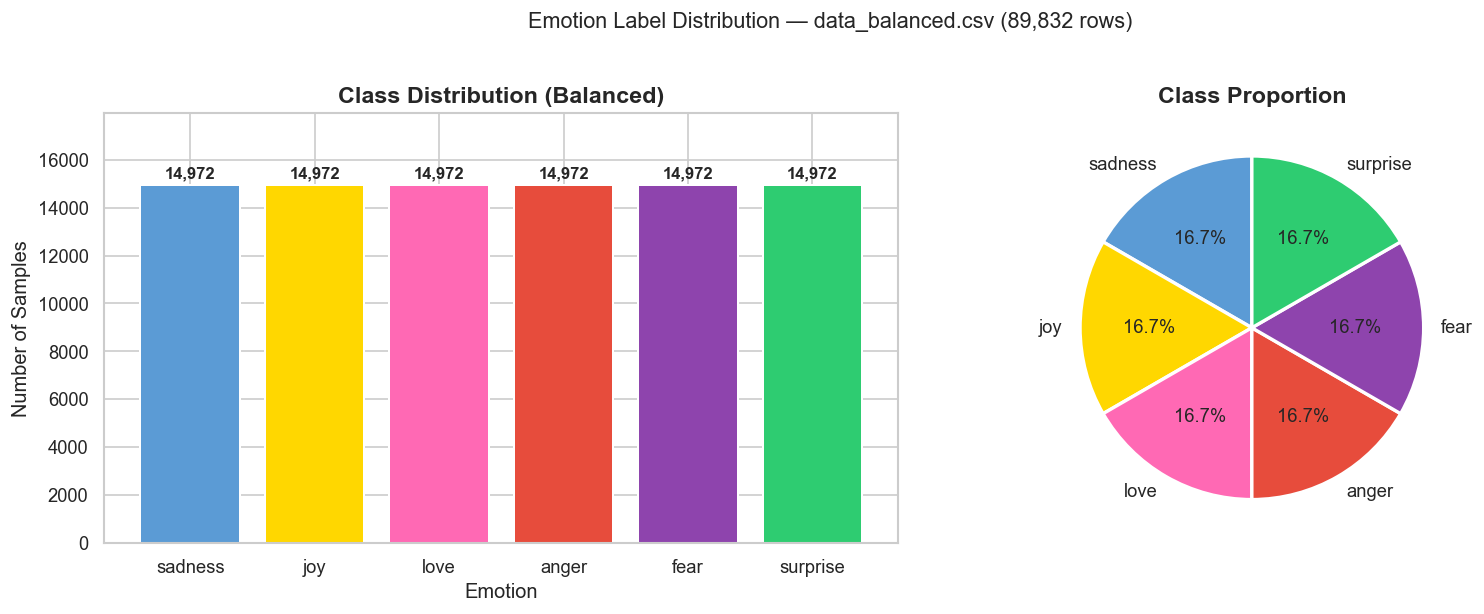

Each class has exactly 14,972 rows (16.7%) — perfectly balanced.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

emotions = [LABEL_MAP[i] for i in range(6)]
counts   = [len(df[df['label'] == i]) for i in range(6)]
colours  = [EMOTION_COLOURS[e] for e in emotions]

# Bar chart
bars = axes[0].bar(emotions, counts, color=colours, edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Distribution (Balanced)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Emotion', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_ylim(0, max(counts) * 1.2)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                 f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
wedge_props = {'linewidth': 2, 'edgecolor': 'white'}
axes[1].pie(counts, labels=emotions, colors=colours, autopct='%1.1f%%',
            startangle=90, wedgeprops=wedge_props, textprops={'fontsize': 11})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Emotion Label Distribution — data_balanced.csv (89,832 rows)', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('B_Q1_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Each class has exactly 14,972 rows (16.7%) — perfectly balanced.')

### EDA 2 — Text Length Analysis

In [5]:
df['text_length']    = df['text'].str.len()
df['word_count']     = df['text'].str.split().str.len()

print('Overall Text Length Statistics (characters):')
print(df['text_length'].describe().round(1).to_string())
print()
print('Overall Word Count Statistics:')
print(df['word_count'].describe().round(1).to_string())

Overall Text Length Statistics (characters):
count    89832.0
mean        98.2
std         56.3
min          4.0
25%         55.0
50%         87.0
75%        130.0
max        525.0

Overall Word Count Statistics:
count    89832.0
mean        19.4
std         11.1
min          1.0
25%         11.0
50%         17.0
75%         26.0
max        100.0


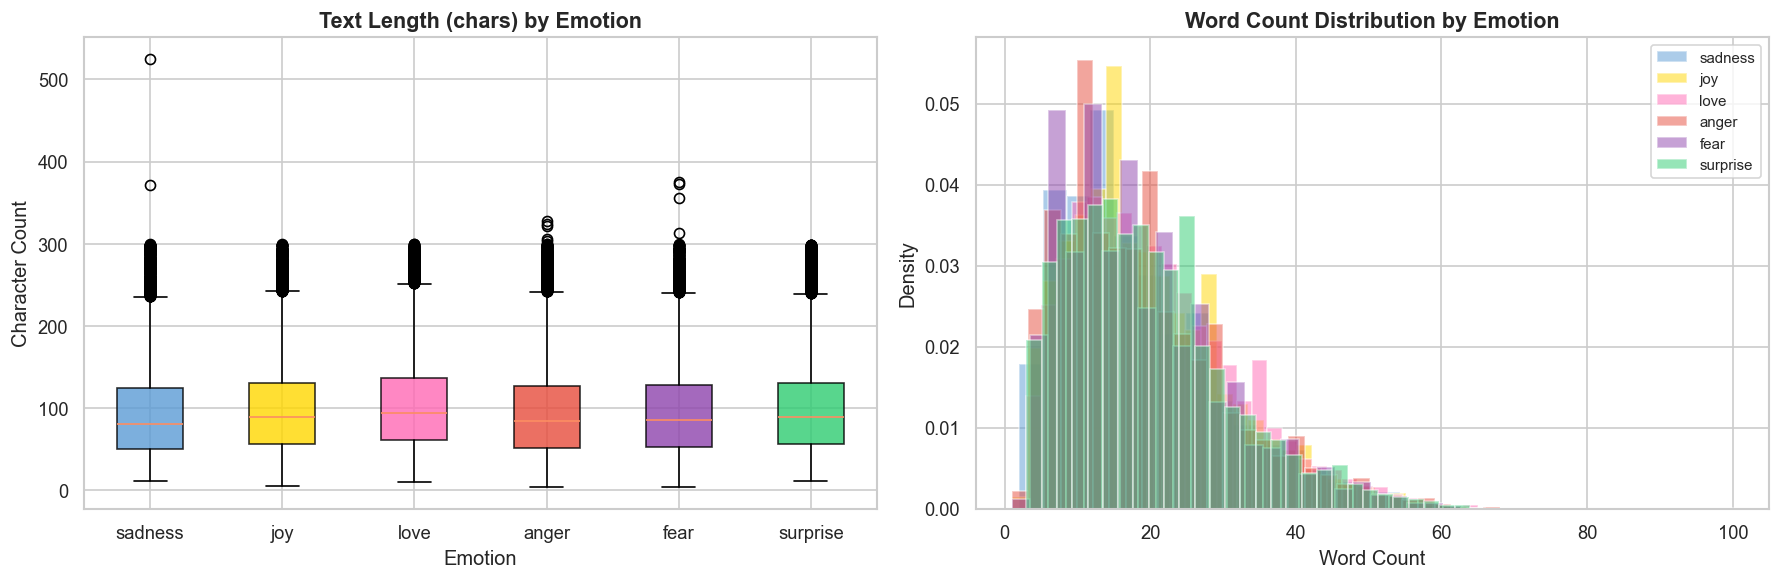

Average text length per emotion (characters):
emotion
love        104.6
surprise     99.7
joy          99.2
fear         96.4
anger        95.9
sadness      93.3


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot — character length per emotion
emotion_order = list(LABEL_MAP.values())
box_data = [df[df['emotion'] == e]['text_length'].values for e in emotion_order]
bp = axes[0].boxplot(box_data, labels=emotion_order, patch_artist=True, notch=False)
for patch, colour in zip(bp['boxes'], colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.8)
axes[0].set_title('Text Length (chars) by Emotion', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Emotion'); axes[0].set_ylabel('Character Count')

# Histogram — word count distribution
for i, (emotion, colour) in enumerate(EMOTION_COLOURS.items()):
    axes[1].hist(df[df['emotion'] == emotion]['word_count'],
                 bins=30, alpha=0.5, color=colour, label=emotion, density=True)
axes[1].set_title('Word Count Distribution by Emotion', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('B_Q1_text_length.png', bbox_inches='tight', dpi=150)
plt.show()

print('Average text length per emotion (characters):')
print(df.groupby('emotion')['text_length'].mean().round(1).sort_values(ascending=False).to_string())

### EDA 3 — Top 15 Most Frequent Words per Emotion

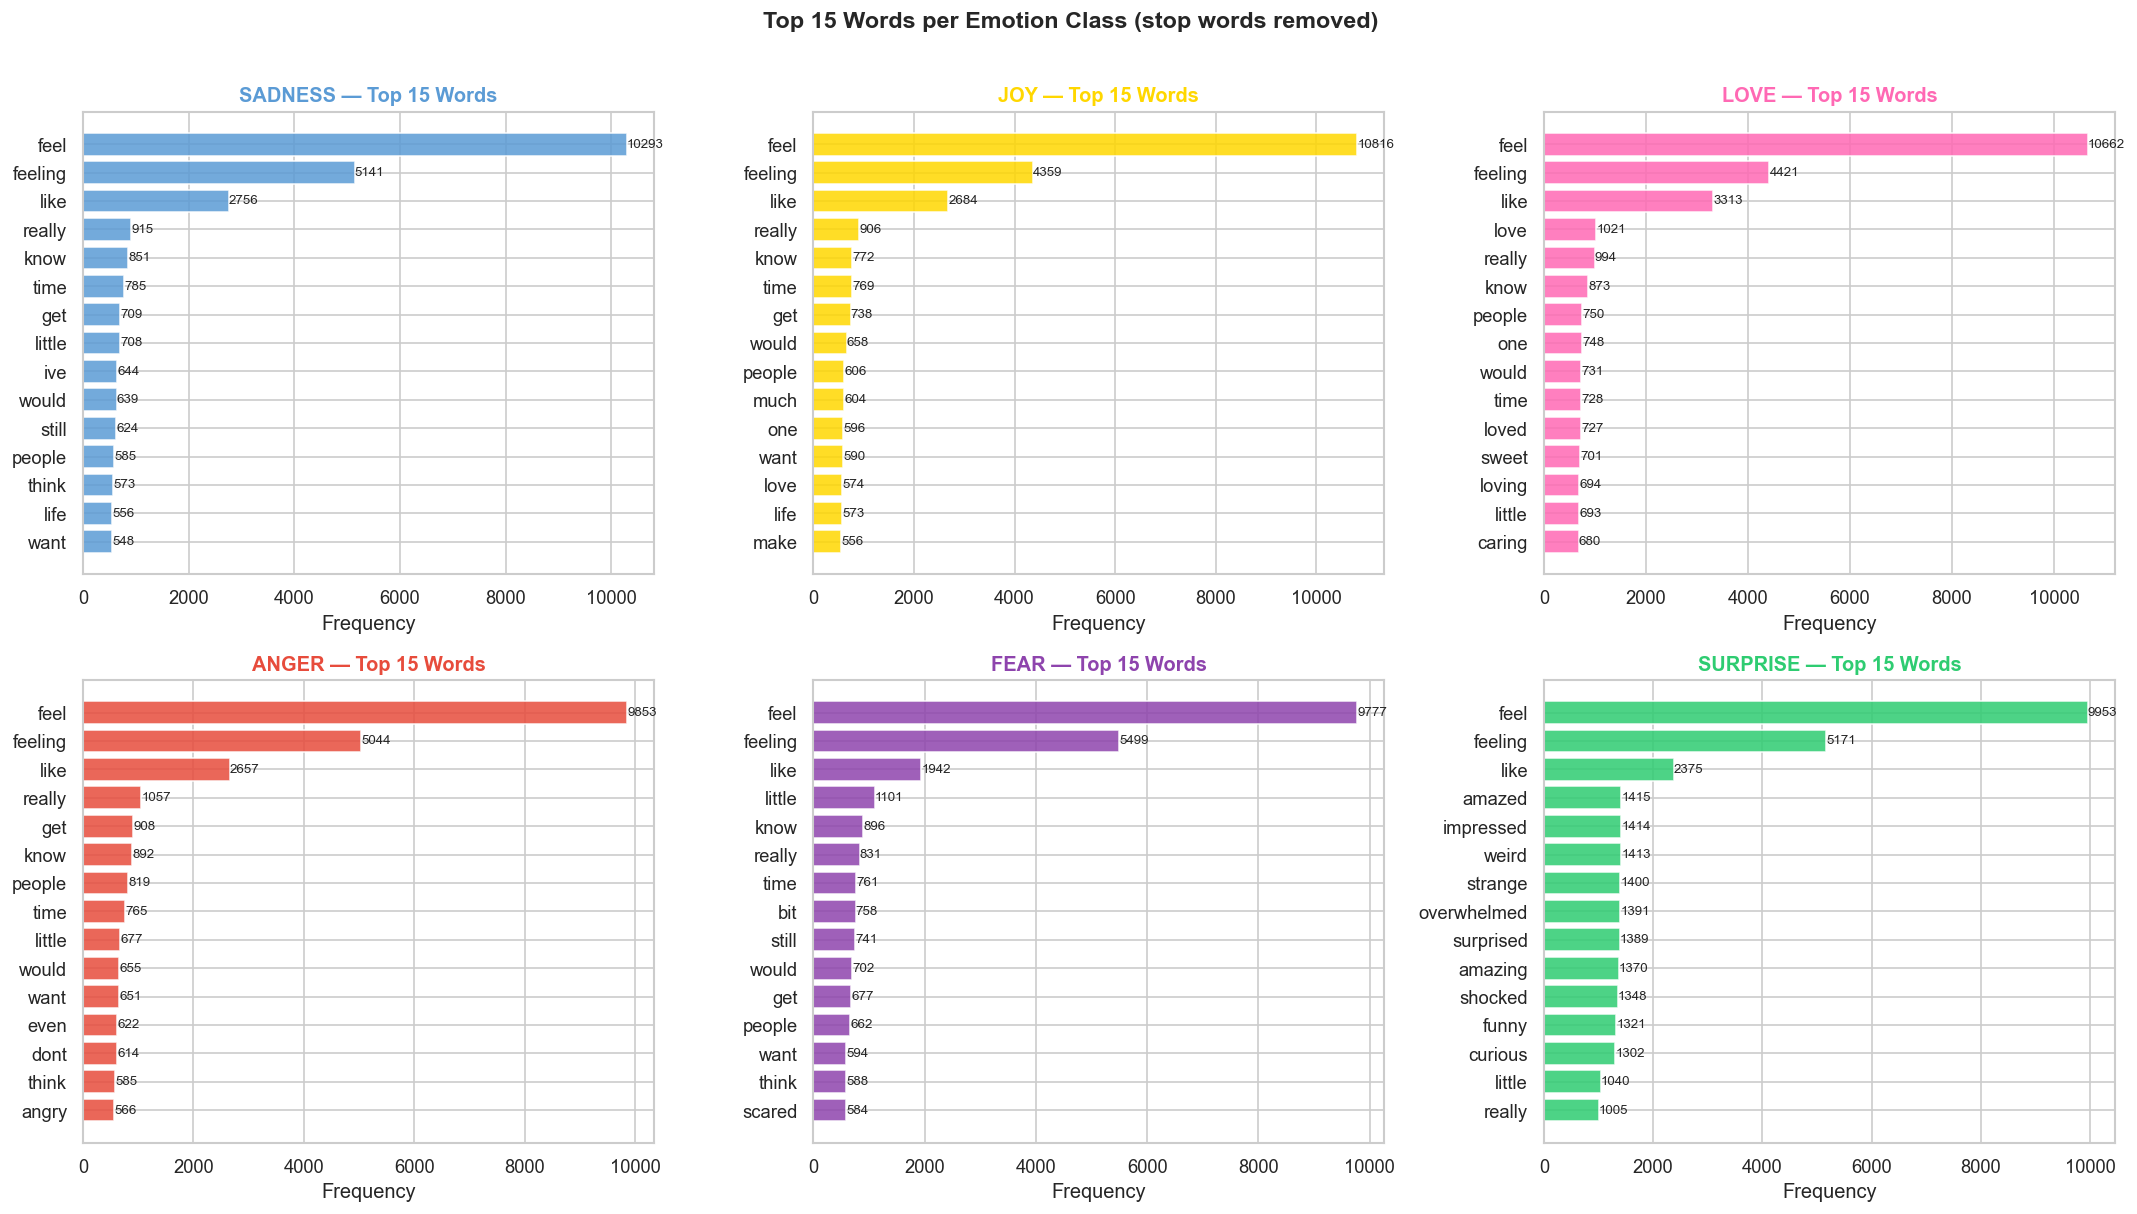

In [7]:
stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=15):
    """Return top-n words after removing stopwords and punctuation."""
    all_words = []
    for text in texts:
        tokens = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
        tokens = [t for t in tokens if t not in stop_words]
        all_words.extend(tokens)
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (label, emotion) in enumerate(LABEL_MAP.items()):
    subset    = df[df['label'] == label]['text']
    top_words = get_top_words(subset, n=15)
    words, counts = zip(*top_words)

    colour = EMOTION_COLOURS[emotion]
    bars   = axes[idx].barh(words[::-1], counts[::-1], color=colour, alpha=0.85)
    axes[idx].set_title(f'{emotion.upper()} — Top 15 Words',
                        fontsize=12, fontweight='bold', color=colour)
    axes[idx].set_xlabel('Frequency')
    for bar, count in zip(bars, counts[::-1]):
        axes[idx].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                       str(count), va='center', fontsize=8)

plt.suptitle('Top 15 Words per Emotion Class (stop words removed)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('B_Q1_top_words.png', bbox_inches='tight', dpi=150)
plt.show()

### EDA 4 — Word Clouds per Emotion

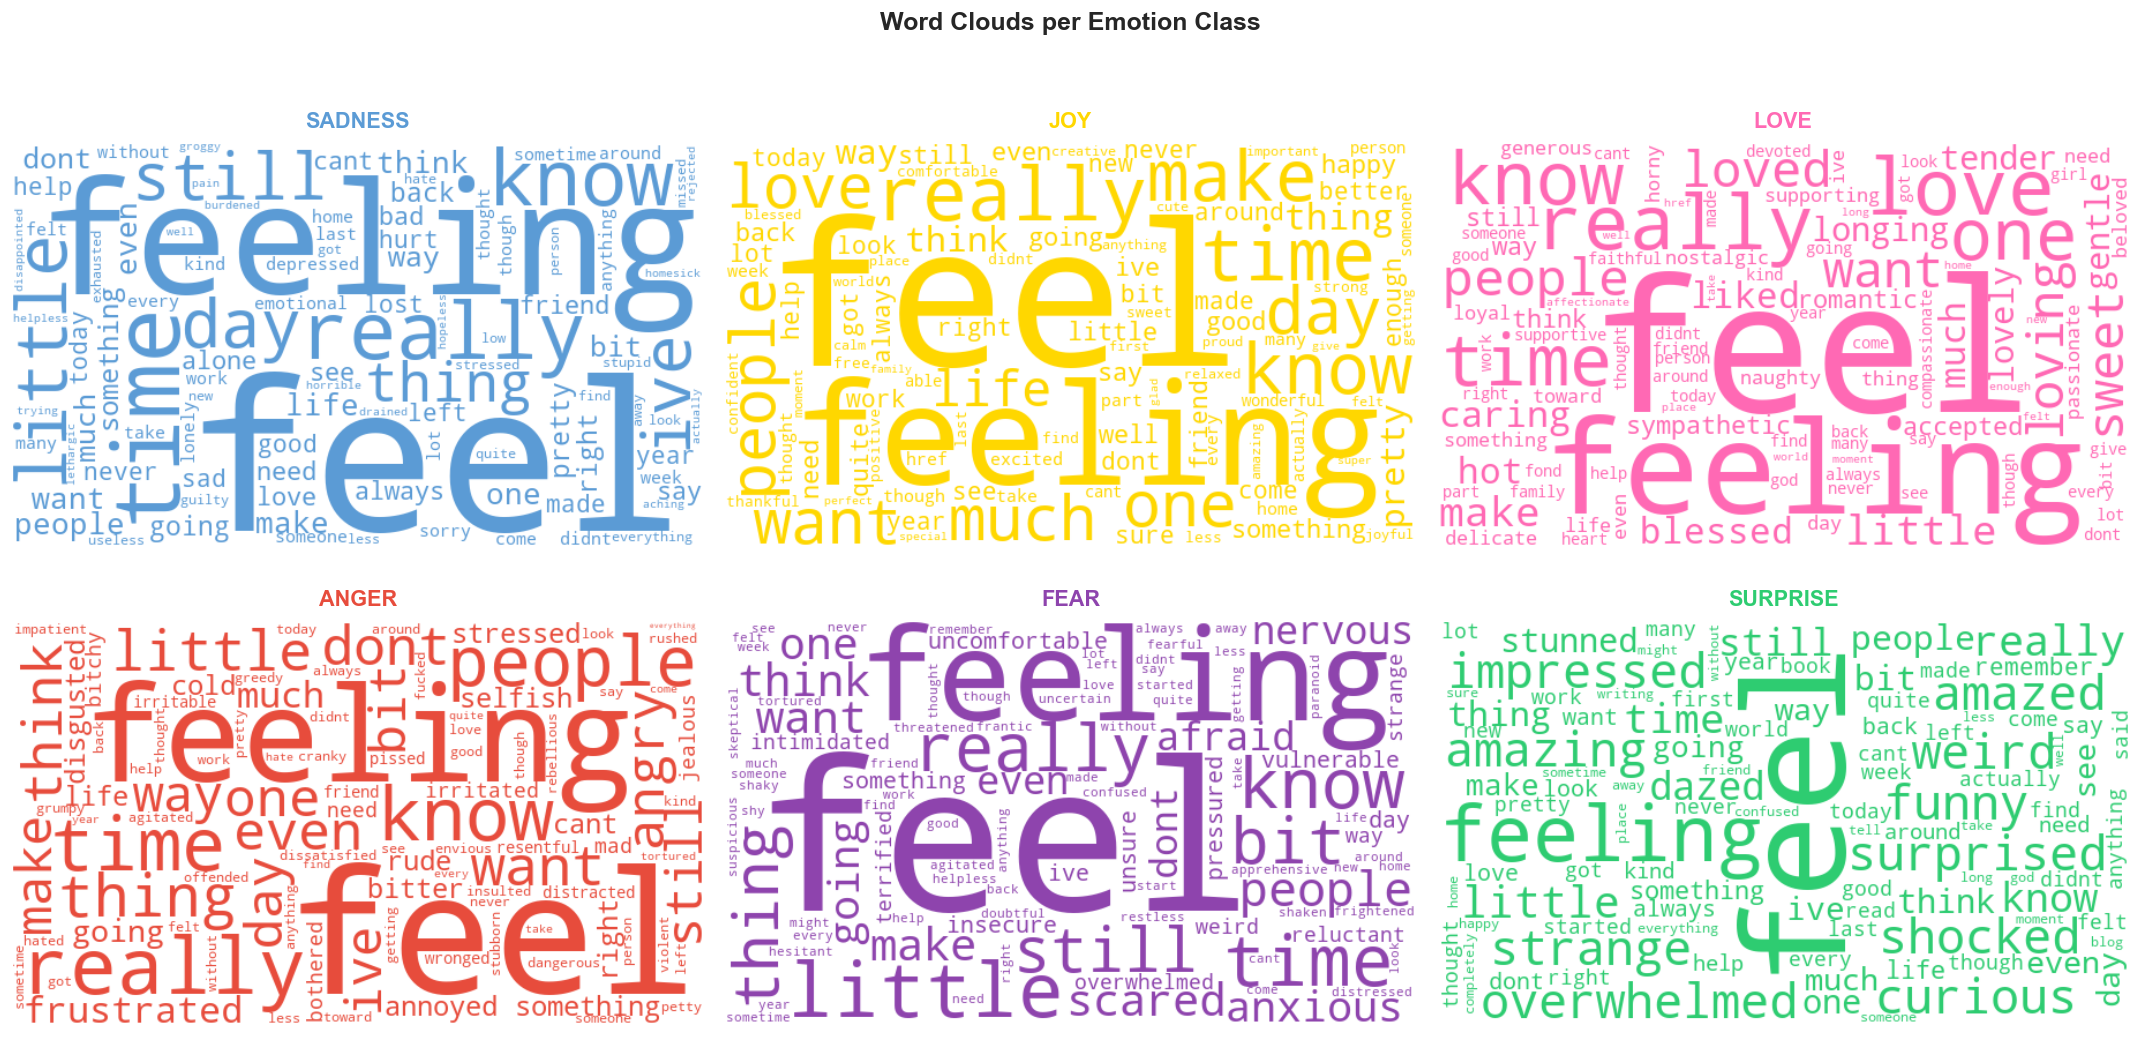

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for idx, (label, emotion) in enumerate(LABEL_MAP.items()):
    # Combine all texts for this emotion, remove stopwords
    corpus = ' '.join(df[df['label'] == label]['text'].tolist())
    tokens = re.findall(r'\b[a-z]{3,}\b', corpus.lower())
    clean  = ' '.join([t for t in tokens if t not in stop_words])

    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        color_func=lambda *args, **kwargs: EMOTION_COLOURS[emotion],
        max_words=100,
        collocations=False
    ).generate(clean)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'{emotion.upper()}', fontsize=13,
                        fontweight='bold', color=EMOTION_COLOURS[emotion],
                        pad=10)

plt.suptitle('Word Clouds per Emotion Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('B_Q1_wordclouds.png', bbox_inches='tight', dpi=150)
plt.show()

### EDA 5 — Top Bigrams per Emotion

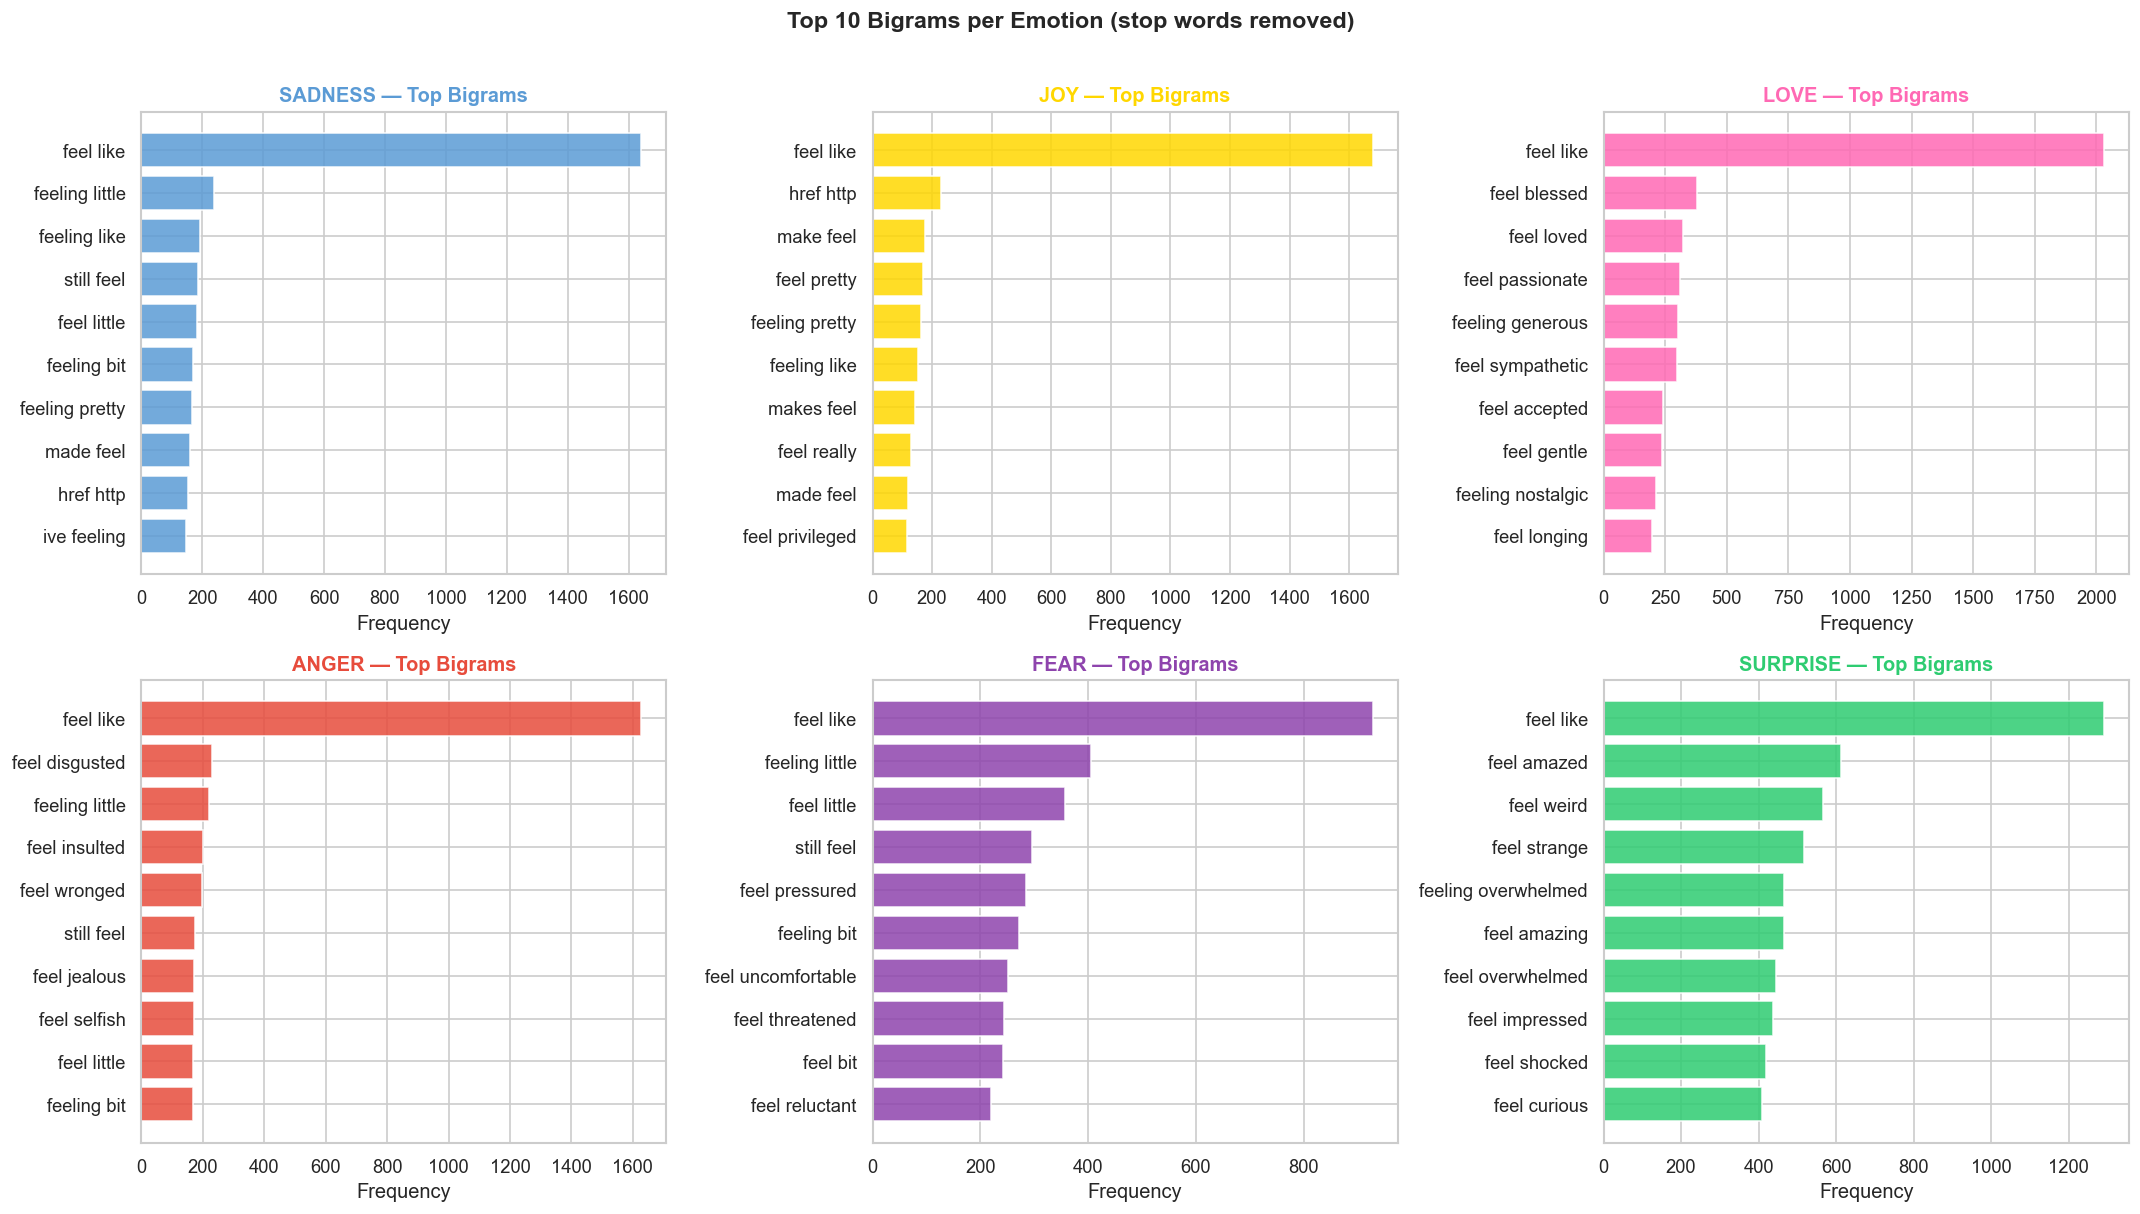

In [9]:
from nltk.util import ngrams

def get_top_bigrams(texts, n=10):
    all_bigrams = []
    for text in texts:
        tokens = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
        tokens = [t for t in tokens if t not in stop_words]
        all_bigrams.extend([' '.join(bg) for bg in ngrams(tokens, 2)])
    return Counter(all_bigrams).most_common(n)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (label, emotion) in enumerate(LABEL_MAP.items()):
    subset     = df[df['label'] == label]['text']
    top_bigrams = get_top_bigrams(subset, n=10)
    if not top_bigrams:
        continue
    bigrams_list, counts = zip(*top_bigrams)
    colour = EMOTION_COLOURS[emotion]
    axes[idx].barh(bigrams_list[::-1], counts[::-1], color=colour, alpha=0.85)
    axes[idx].set_title(f'{emotion.upper()} — Top Bigrams',
                        fontsize=12, fontweight='bold', color=colour)
    axes[idx].set_xlabel('Frequency')

plt.suptitle('Top 10 Bigrams per Emotion (stop words removed)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('B_Q1_bigrams.png', bbox_inches='tight', dpi=150)
plt.show()

### EDA 6 — Correlation Heatmap of Word Overlap Between Emotions

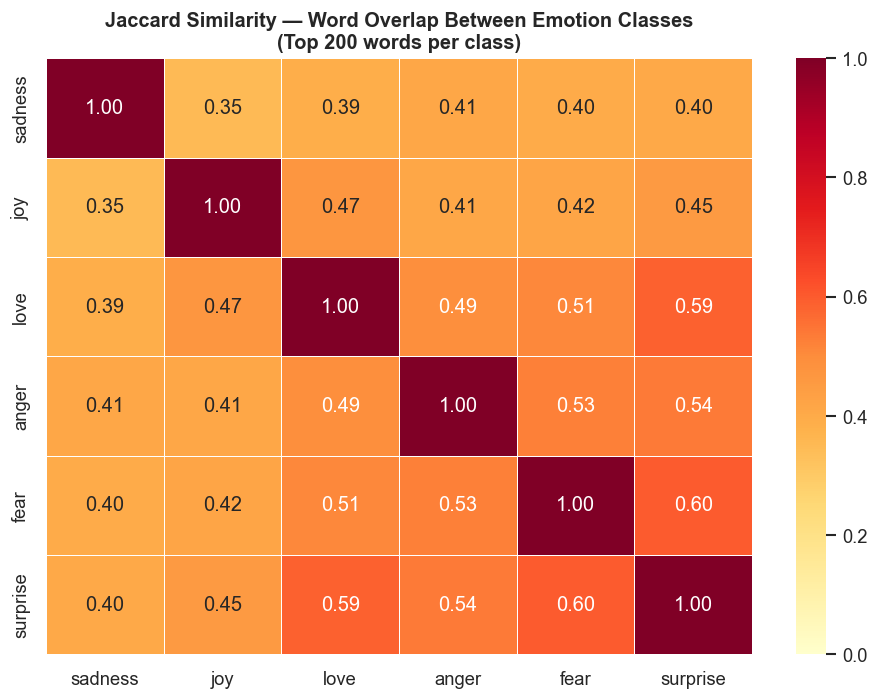

Higher Jaccard score = more word overlap = harder to distinguish.
Lower Jaccard score = more distinct vocabulary = easier for classifiers.


In [10]:
# Build top-200 word sets per emotion and compute Jaccard similarity
def top_word_set(texts, n=200):
    all_words = []
    for text in texts:
        tokens = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
        tokens = [t for t in tokens if t not in stop_words]
        all_words.extend(tokens)
    return set([w for w, _ in Counter(all_words).most_common(n)])

emotion_word_sets = {
    LABEL_MAP[i]: top_word_set(df[df['label'] == i]['text'])
    for i in range(6)
}

emotions_list = list(LABEL_MAP.values())
jaccard_matrix = np.zeros((6, 6))
for i, e1 in enumerate(emotions_list):
    for j, e2 in enumerate(emotions_list):
        inter = len(emotion_word_sets[e1] & emotion_word_sets[e2])
        union = len(emotion_word_sets[e1] | emotion_word_sets[e2])
        jaccard_matrix[i, j] = inter / union if union > 0 else 0

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(jaccard_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=emotions_list, yticklabels=emotions_list,
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Jaccard Similarity — Word Overlap Between Emotion Classes\n(Top 200 words per class)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('B_Q1_word_overlap.png', bbox_inches='tight', dpi=150)
plt.show()

print('Higher Jaccard score = more word overlap = harder to distinguish.')
print('Lower Jaccard score = more distinct vocabulary = easier for classifiers.')

---
## Suggested Predictive Models

Based on the EDA, four supervised text classification models are proposed — one per group member:

| Model | Member | Justification |
|---|---|---|
| **Naïve Bayes** (MultinomialNB) | Member 1 | Fast probabilistic baseline; works well with TF-IDF sparse features; widely used in text classification literature |
| **Logistic Regression** | Member 2 | Strong linear baseline for high-dimensional text; interpretable coefficients reveal most predictive words per emotion |
| **Linear SVM** (LinearSVC) | Member 3 | State-of-the-art for sparse TF-IDF text vectors; maximises class margin; robust to high dimensionality |
| **Random Forest** | Member 4 | Non-linear ensemble method; captures word interaction patterns; provides feature importance scores |

These four models span a range of complexity (probabilistic → linear → kernel → ensemble), enabling a meaningful comparison in Q4.

### EDA Summary

In [11]:
print('=' * 60)
print('EDA SUMMARY')
print('=' * 60)
print(f'Total samples         : {len(df):,}')
print(f'Samples per class     : {len(df)//6:,} (perfectly balanced)')
print(f'Avg text length       : {df["text_length"].mean():.1f} characters')
print(f'Avg word count        : {df["word_count"].mean():.1f} words')
print(f'Shortest text         : {df["text_length"].min()} characters')
print(f'Longest text          : {df["text_length"].max()} characters')
print()
print('Key EDA Findings:')
print('  1. Perfect class balance (16.7% each) — no imbalance bias in training.')
print('  2. Love has longest avg text length; sadness is shortest.')
print('  3. Word clouds show distinct vocabulary per emotion:')
print('     - Joy: happy, excited, grateful, wonderful')
print('     - Anger: frustrated, annoyed, hate, furious')
print('     - Fear: scared, worried, anxious, afraid')
print('  4. Jaccard overlap: sadness-fear are most similar (hard to distinguish).')
print('     joy-anger are most distinct (easier to classify).')
print('  5. Bigrams reveal phrase patterns: "feel happy", "feel sad", "feel scared".')
print()
print('Preprocessing plan for Q2:')
print('  - Lowercase all text')
print('  - Remove punctuation and digits')
print('  - Remove English stop words')
print('  - TF-IDF vectorization (unigrams + bigrams, max_features=10,000)')
print('  - Train/test split: 80/20, stratified, random_state=42')

EDA SUMMARY
Total samples         : 89,832
Samples per class     : 14,972 (perfectly balanced)
Avg text length       : 98.2 characters
Avg word count        : 19.4 words
Shortest text         : 4 characters
Longest text          : 525 characters

Key EDA Findings:
  1. Perfect class balance (16.7% each) — no imbalance bias in training.
  2. Love has longest avg text length; sadness is shortest.
  3. Word clouds show distinct vocabulary per emotion:
     - Joy: happy, excited, grateful, wonderful
     - Anger: frustrated, annoyed, hate, furious
     - Fear: scared, worried, anxious, afraid
  4. Jaccard overlap: sadness-fear are most similar (hard to distinguish).
     joy-anger are most distinct (easier to classify).
  5. Bigrams reveal phrase patterns: "feel happy", "feel sad", "feel scared".

Preprocessing plan for Q2:
  - Lowercase all text
  - Remove punctuation and digits
  - Remove English stop words
  - TF-IDF vectorization (unigrams + bigrams, max_features=10,000)
  - Train/test